## Tutorial – Deutsch's Algorithm (1-Qubit Oracle)

**Instructor:** Hoa Nguyen, Data61 at CSIRO

This tutorial covers the **Deutsch algorithm**: the simplest quantum algorithm that shows a quantum advantage. We use a **1-qubit oracle** (one input qubit, one output qubit).

#### **Note**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

Code snippets will be provided for you, except in certain cells where your task will be to complete the code to ensure our quantum program runs smoothly. These cells will be clearly marked with a comment like: <span style="font-family: monospace; font-weight: bold; color: #111; background-color: #fff8dc; padding: 2px 6px; border-radius: 4px;"> ### WRITE YOUR CODE BELOW THIS CELL ### </span>. Please also note that we’ll be running our quantum programs exclusively on simulators. No worries—these work perfectly well for our learning purposes.

This lab focuses on **Deutsch's algorithm** with a **1-qubit oracle**: we determine whether a Boolean function $f: \{0,1\} \to \{0,1\}$ is **constant** or **balanced** using a single quantum query.

</div>

## **Pre-checking and Imports**


<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
You should check your Qiskit version before starting the lab. It is recommended to use Qiskit version 2.0 or higher for the best experience.
</div>

In [1]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram
import random as rd

## **Problem**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

We are given a Boolean function $f(x)$ that takes **one bit** $x \in \{0,1\}$ and returns $0$ or $1$.

- **Constant function**: $f(0) = f(1)$ — either always $0$ or always $1$.

- **Balanced function**: $f(0) \neq f(1)$ — one input gives $0$, the other gives $1$.
  
**Our goal** is to determine whether $f$ is **constant** or **balanced**.

</div>

### **Classical Approach**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
  
**Classically**, we need **2 evaluations** in the worst case: we must check both $f(0)$ and $f(1)$. If they are equal, $f$ is constant; if they differ, $f$ is balanced.
</div>

### **Modeling the Problem with the Quantum Approach**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

With the quantum approach, we only need to query the hidden function $f$ **once** to achieve our goal. Similar to the classical case, we also need to construct both a balanced and a constant version of the function within the quantum circuit, which we will be able to distinguish with just a single query!

The idea is straightforward: we use $n$ qubits as the input, along with one additional qubit representing the function’s output—often referred to as the output qubit. We use 1 input qubit and 1 output qubit (2 qubits total).

- **Constant oracle**: The output qubit is either left unchanged ($f \equiv 0$) or flipped with $X$ ($f \equiv 1$).

- **Balanced oracle**: CNOT (input = control, output = target) gives $f(0)=0$, $f(1)=1$.

The algorithm uses one oracle call to distinguish constant vs balanced.

</div>

## **Designing Constant and Balanced Functions**

In [3]:
# Deutsch algorithm: 1 input qubit, 1 output qubit
n_input = 1
qreg_input = QuantumRegister(n_input, name="input")
qreg_output = QuantumRegister(1, name="output")
creg = ClassicalRegister(n_input, name="result")

### **Constant Oracle**

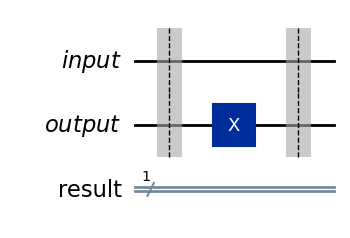

In [6]:
# Randomization for more diverse output behavior
output = rd.choice([0, 1])

constant_oracle = QuantumCircuit(qreg_input, qreg_output, creg)

# Add a barrier to make the circuit easier to visualize
constant_oracle.barrier()

if output == 1:
    constant_oracle.x(qreg_output)
constant_oracle.barrier()

constant_oracle.draw('mpl')

### **Balanced Oracle**


In [7]:
# Generate a random qubit string; qubits with value 1 will be assigned an X gate
# The order from left to right corresponds to the output, input n−1, input n−2, input n−3, and so on.
qstr = format(rd.randint(1, 2**n_input - 1) , '0' + str(n_input) + 'b') 
qstr[::-1]  # Reverse the string to match qubit order

'1'

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 1: Designing a Balanced Oracle**
  
Your task is to design a quantum circuit representing a Balanced Function, which ensures that the outputs always contain an equal number of 0s and 1s. At the same time, maintain diversity in the ordering of the output. Follow these steps:
  
1. For a randomly generated qubit string, apply X gates to the qubits marked as 1 in the string.
2. Apply CNOT gates using the input qubits as control qubits and the output qubit as the target.
3. Undo the X gates added in step 1 to preserve the correctness of the function.
</div>

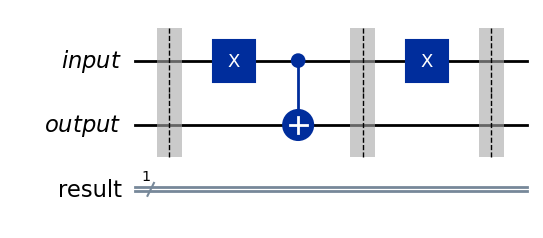

In [ ]:
balanced_oracle = QuantumCircuit(qreg_input, qreg_output, creg)

balanced_oracle.barrier()

### WRITE YOUR CODE BELOW THIS CELL ###

# Loop through the elements of the qubit string
for i, bit in enumerate(qstr[::-1]):
    # Apply an X gate if the current qubit is 1
    
        
# Loop over the input qubits
for i in range(len(qreg_input)):
    # Apply a CNOT gate with the input qubit as control and the output qubit as target
    

# Add a barrier to make the circuit easier to visualize
balanced_oracle.barrier()
# Loop through the elements of the qubit string
for i, bit in enumerate(qstr[::-1]):
    # Apply an X gate if the current qubit is 1
    

### YOUR CODE FINISHES HERE ###
balanced_oracle.barrier()

balanced_oracle.draw('mpl')

## **The Deutsch Algorithm**

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
 
We assume that the function fed into the quantum circuit of the algorithm is **unknown**; it could be either a balanced function or a constant function, and the choice of which function to use is made **randomly**.
</div>

In [9]:
# Assume that the function selection is performed randomly
oracle = rd.choice(["balanced", "constant"])

In [10]:
oracle

'balanced'

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 2: Designing the Algorithm**
  
Your task is to **design an algorithm** to **determine** whether the function fed into the quantum circuit via the random function above is constant or balanced *(keep everything secret!)*. Follow these steps to construct the algorithm:

1. Create a quantum circuit with the existing registers.
2. Prepare $|-
angle$ on the output qubit: apply $X$ then $H$.
3. Apply $H$ to the input qubit (superposition).
4. Apply the oracle.
5. Apply $H$ to the input qubit.
6. Measure the input qubit.

</div>

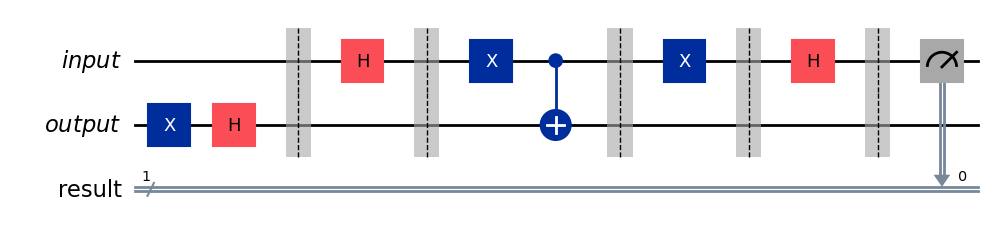

In [ ]:
dj_circuit = QuantumCircuit(qreg_input, qreg_output, creg)

### WRITE YOUR CODE BELOW THIS CELL ###
# Apply an X gate to the output qubit


# Apply a Hadamard gate to the output qubit to prepare the |−⟩ state

# Add a barrier to make the circuit easier to visualize

# Loop over the input qubits
for i in range(len(qreg_input)):
    # Apply Hadamard gates to all input qubits
    

# Apply the hidden (oracle) function to the quantum circuit


# Loop over all input qubits again

    # Apply Hadamard gates to all input qubits after applying the function


# Add a barrier to make the circuit easier to visualize.

# Loop over all input qubits
for i in range(len(qreg_input)):
    # Apply measurement gates
    
### YOUR CODE FINISHES HERE ###

dj_circuit.draw('mpl')

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   
 
Great! After completing the steps above, we can see our quantum circuit fully constructed. By visually inspecting the simulated circuit, you might already get a sense of what kind of function it represents!
  
However, suppose the function is still hidden inside a **“black box.”** To determine its nature, we measure the classical outputs of the input qubits. As expected:
- **Constant** → measurement is always $0$.
- **Balanced** → measurement is always $1$.
</div>

<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify; color: #111; background-color: #fff8dc; padding: 15px; border-radius: 8px;">   

**Exercise 3: Verifying the Algorithm**
  
Your task is to run the quantum algorithm on a simulator and read the results. Based on the measurements, determine whether the function is balanced or constant.
</div>

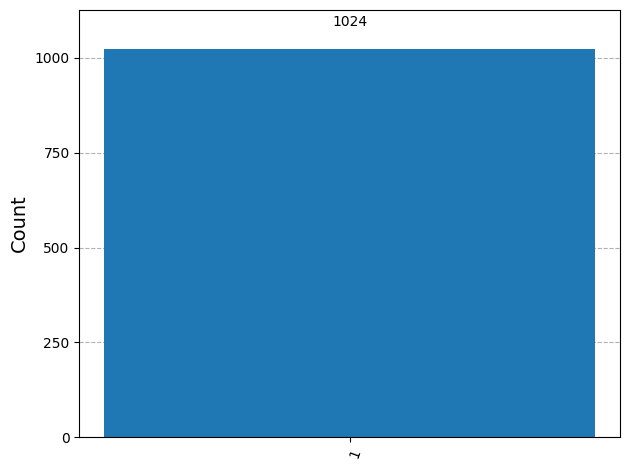

In [ ]:
### WRITE YOUR CODE BELOW THIS CELL ###

# Initialize the quantum backend
backend_simulator =  
# Compile the quantum circuit
transpiled_circ =  
# Execute the quantum circuit with 1024 shots
job =  
# Retrieve the result of the execution job
result =  
# Count the occurrences of each measurement outcome using the get_counts() method
counts =  
### YOUR CODE FINISHES HERE ###

plot_histogram(counts)

In [13]:
# Check which oracle was used
# For 1 qubit: all 0s -> constant; otherwise -> balanced
if counts.get('0'*n_input, 0) == 1024:
    print("The oracle used was: constant")
else:
    print("The oracle used was: balanced")

The oracle used was: balanced


## **Congratulations!**


<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">   

**Congratulations!**

You have completed the **Deutsch algorithm** (1-qubit oracle) tutorial. It shows that one quantum query can distinguish constant from balanced, while classically we need two evaluations.

</div>